# Explain Like I'm 5

![Architecture](images/architecture.png)

In this notebook, we're going to walk through setting up a simple chatbot in LangGraph. 

Throughout this process, we're going to show how LangSmith can be used to improve the developer experience for AI applications. 

Let's start by loading our environment variables from our .env file. 

In [1]:
from dotenv import load_dotenv
load_dotenv(dotenv_path=".env", override=True)
# Loads the following env variables
# LANGSMITH_TRACING=true
# LANGSMITH_ENDPOINT="https://api.smith.langchain.com"
# LANGSMITH_PROJECT="eli5-bot"
# LANGSMITH_API_KEY="<redacted>"

# GOOGLE_API_KEY="<redacted>"
# OPENAI_API_KEY="<redacted>"
# TAVILY_API_KEY="<redacted>"

True

## Setup

Let's set up a tool called Tavily to allow our assistant to search the web when answering

In [2]:
# from langchain_community.tools.tavily_search import TavilySearchResults
#
# web_search_tool = TavilySearchResults(max_results=1)

Let's design a prompt for RAG that we'll use throughout the notebook.

In [2]:
prompt = """You are a professor and expert in explaining complex topics in a way that is easy to understand. 
Your job is to answer the provided question so that even a 5 year old can understand it. 
You have provided with relevant background context to answer the question.

Question: {question} 

Context: {context}

Answer:"""
print("Prompt Template: ", prompt)

Prompt Template:  You are a professor and expert in explaining complex topics in a way that is easy to understand. 
Your job is to answer the provided question so that even a 5 year old can understand it. 
You have provided with relevant background context to answer the question.

Question: {question} 

Context: {context}

Answer:


## Creating Our Application

In [3]:
import os
from google import genai
from langsmith import traceable

client = genai.Client(api_key=os.getenv("GOOGLE_API_KEY"))
chat = client.chats.create(model="gemini-3.5-flash-lite")

@traceable
def search(question):
    # try:
    #     if "web_search_tool" in globals():
    #         web_docs = web_search_tool.invoke({"query": question})
    #         return "\n".join([d["content"] for d in web_docs])
    # except Exception:
    #     pass
    return (
        f"General knowledge context for: {question}. "
        "Answer in simple language using clear examples and short explanations."
    )
    
@traceable
def explain(question, context):
    formatted = prompt.format(question=question, context=context)
    response = chat.send_message(formatted)
    content = response.text
    return str(content)

@traceable
def eli5(question):
    context = search(question)
    answer = explain(question, context)
    return answer


## Testing Our Application

In [4]:
question = "What is LangChain?"
print(eli5(question))

Hello there! Imagine you have a super-smart robot brain, like a giant computer that knows almost everything. This robot brain is amazing at talking and writing, but it doesn't know what happened *today*, and it can't look at your personal toy box. 

**LangChain** is like a magical set of building blocks that helps connect that smart robot brain to the rest of the world! 

Think of it like giving the robot:
1. **A pair of glasses** so it can read your favorite books.
2. **A telephone** so it can look things up on the internet.
3. **A backpack** to remember what you told it yesterday.

So, LangChain is just a helper tool that helps smart computer brains do even more cool things!


## Application Using LangGraph

Let's define the State for our Graph. We'll track the user's question, our application's generation, and the list of relevant documents.

In [7]:
import os
from google import genai
from langchain_core.documents import Document
from typing import List
from typing_extensions import TypedDict

client = genai.Client(api_key=os.getenv("GOOGLE_API_KEY"))
chat = client.chats.create(model="gemini-3.5-flash-lite")

class GraphState(TypedDict):
    """
    Represents the state of our graph.

    """
    question: str
    documents: List[str]
    messages: List[str]


Great, now let's define the nodes of our graph

In [8]:
def search(state):
    """
    Web search based on the re-phrased question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with appended web results
    """
    question = state["question"]
    documents = state.get("documents", [])

    web_results = chat.send_message(f"Give a concise factual background summary for: {question}.").text
    web_results = Document(page_content=web_results)
    documents.append(web_results)

    return {"documents": documents}


In [ ]:
def explain(state: GraphState):
    """
    Generate response
    Args:
        state (dict): The current graph state
    Returns:
        state (dict): New key added to state, generation, that contains LLM generation
    """
    question = state["question"]
    documents = state.get("documents", [])
    formatted = prompt.format(question=question, context="\n".join([d.page_content for d in documents]))
    generation = chat.send_message(formatted)
    return {"question": question, "messages": [generation]}


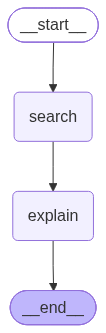

In [9]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

graph = StateGraph(GraphState)
graph.add_node("explain", explain)
graph.add_node("search", search)
graph.add_edge(START, "search")
graph.add_edge("search", "explain")
graph.add_edge("explain", END)

app = graph.compile()
display(Image(app.get_graph().draw_mermaid_png()))

## Testing Our Graph

Let's create a helper function to pretty print our results

In [12]:
def ask(question: str):
    for output in app.stream({"question": question}, stream_mode="updates"):
        if END in output or START in output:
            continue
        for key, value in output.items():
            if "messages" in value:
                msg = value["messages"][0]
                text = getattr(msg, "text", None)
                if text is None and hasattr(msg, "content"):
                    text = msg.content
                if isinstance(text, list):
                    text = "".join(part.get("text", "") if isinstance(part, dict) else str(part) for part in text)
                print(text)


Finally, let's test our chatbot out and see how it works!

In [13]:
question = "What is complexity economics?"
ask(question)

Imagine the economy isn't a neat, quiet machine where everything always balances out perfectly. Instead, think of it like a giant playground filled with kids playing tag. 

No one is in charge, and everyone is different—some are fast, some are slow, and they all keep changing their minds about what game to play next! 

Complexity economics is the study of how all those little, everyday choices we make bounce off each other and create big, surprising things—like a brand-new toy everyone suddenly wants, or a sudden game of "the floor is lava!" It’s all about how a messy group of changing people keeps the whole world spinning.
